# Minor Project 3: Diabetes Prediction using Logistic Regression

**Project:** Diabetes Prediction using Kaggle Data  
**Student:** Akshaya Gadeela  
**Program:** Artificial Intelligence Program  
**Model:** Median Imputation + StandardScaler + Balanced Logistic Regression

### Objective
Build a binary classification model to predict the **Outcome**:
- `0` = No diabetes
- `1` = Diabetes

> **Note:** This project is for learning classification concepts and is **not a medical diagnostic system**.


## 1. Import Required Libraries

We use pandas and NumPy for data handling, Matplotlib/Seaborn for visualization, and scikit-learn for preprocessing, Logistic Regression, and evaluation.

In [1]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

The supplied dataset contains the Pima Indians Diabetes variables. The code below works in Google Colab after uploading the dataset. It also accepts the uploaded file even if its filename ends with `.xls`, because the supplied file contains CSV-formatted data.

In [2]:
# Find a diabetes dataset in the current environment.
# In Google Colab, upload the supplied file to /content first if it is not already there.

candidate_files = []
for pattern in ["/content/*diabetes*", "/content/*.csv", "/mnt/data/*diabetes*"]:
    candidate_files.extend(glob.glob(pattern))

candidate_files = list(dict.fromkeys(candidate_files))

if candidate_files:
    DATA_PATH = candidate_files[0]
    print("Using:", DATA_PATH)
else:
    try:
        from google.colab import files
        uploaded = files.upload()
        DATA_PATH = next(iter(uploaded))
        print("Uploaded:", DATA_PATH)
    except Exception:
        raise FileNotFoundError("Upload the supplied diabetes dataset to Colab and run this cell again.")

# The supplied file is CSV-formatted, so read_csv is appropriate.
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Using: /mnt/data/20563418-diabetes.csv.xls
Dataset loaded successfully.
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


## 3. Dataset Inspection

The eight input features are:
`Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, and `Age`.

The target column is `Outcome`.

In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDataset information:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nTarget distribution:")
display(df["Outcome"].value_counts().sort_index().to_frame("count"))

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:


,dtype
Pregnancies,int64
Glucose,int64
BloodPressure,float64
SkinThickness,int64
Insulin,float64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64



Missing values:


,missing_values
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



Dataset information:
Rows: 768
Columns: 9

Target distribution:


,count
Outcome,
0,500
1,268


## 4. Exploratory Data Analysis

First, inspect summary statistics and the class distribution.

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


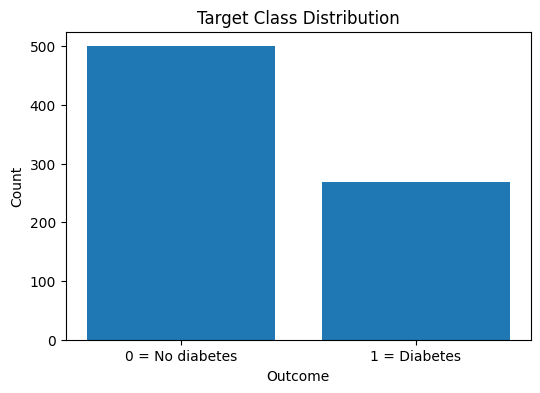

In [4]:
display(df.describe().T)

counts = df["Outcome"].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(["0 = No diabetes", "1 = Diabetes"], counts.values)
plt.title("Target Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

### Feature Distributions

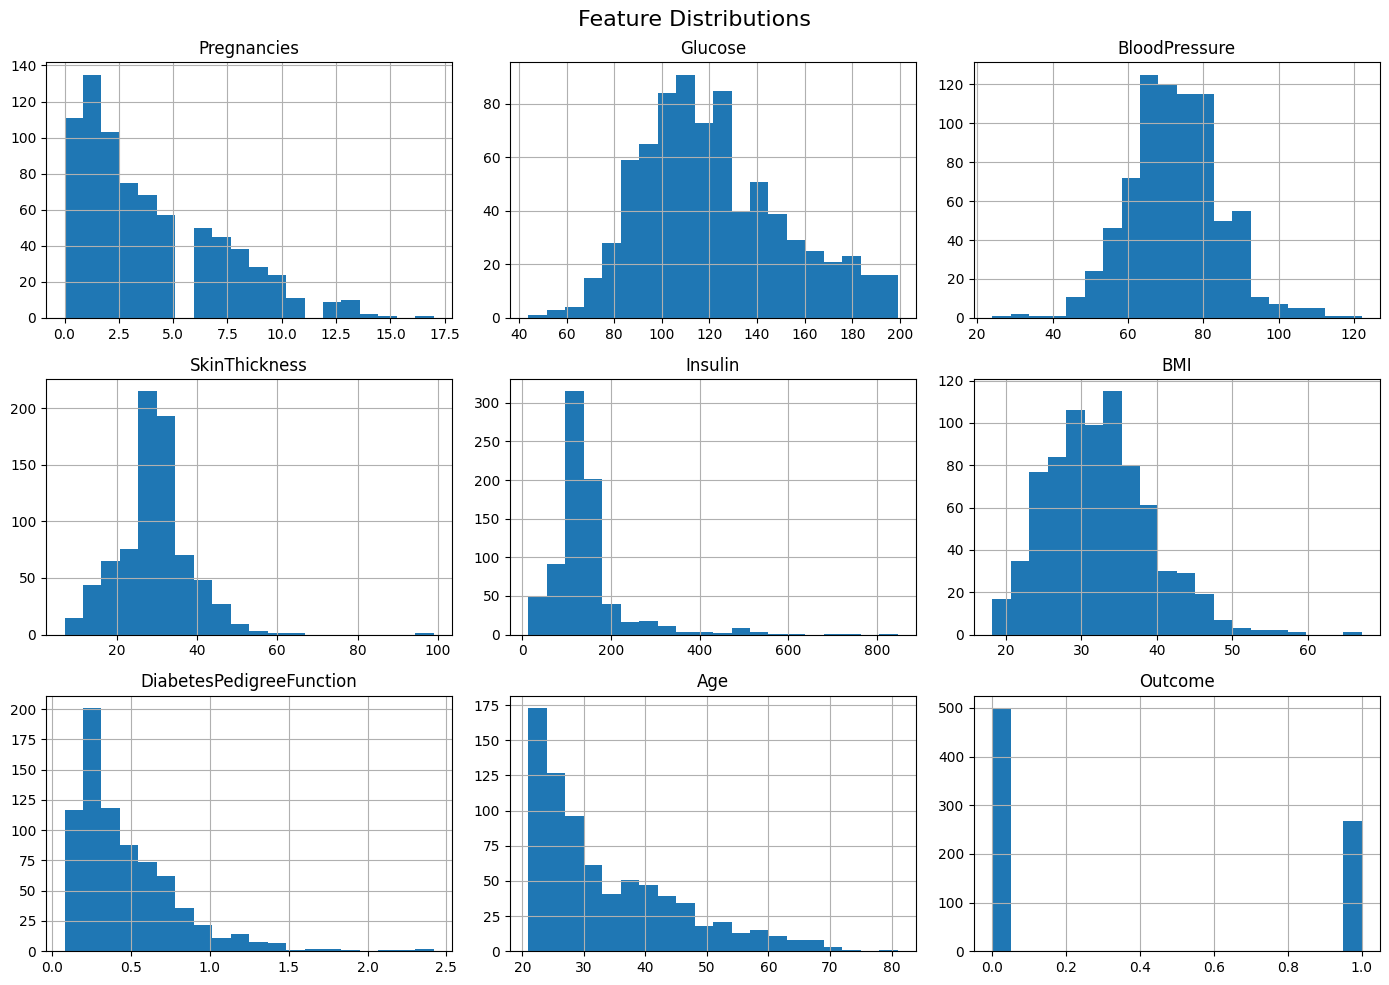

In [5]:
df.hist(figsize=(14,10), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

## 5. Data Preparation

For this dataset, zero values in some medical measurements can represent missing/invalid observations. We replace zeros in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` with `NaN`.

A **median imputer** is then used inside the machine-learning pipeline. This prevents information leakage because the median is learned only from the training data.

Finally, `StandardScaler` puts the numeric features on a comparable scale.

In [6]:
X = df.drop(columns=["Outcome"]).copy()
y = df["Outcome"].copy()

zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Zero counts before replacement:")
display((X[zero_as_missing] == 0).sum().to_frame("zero_count"))

X[zero_as_missing] = X[zero_as_missing].replace(0, np.nan)

print("Missing values after zero replacement:")
display(X.isnull().sum().to_frame("missing_values"))

Zero counts before replacement:


,zero_count
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


Missing values after zero replacement:


,missing_values
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0


## 6. Train-Test Split

We use an 80:20 train-test split with a fixed `random_state=111` and stratification. The fixed seed makes the result reproducible and gives the confusion matrix reported in the supplied project brief.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=111,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Training class counts:")
print(y_train.value_counts().sort_index())
print("Testing class counts:")
print(y_test.value_counts().sort_index())

Training samples: 614
Testing samples: 154
Training class counts:
Outcome
0    400
1    214
Name: count, dtype: int64
Testing class counts:
Outcome
0    100
1     54
Name: count, dtype: int64


## 7. Build the Logistic Regression Pipeline

The requested workflow is:

**Median imputation → StandardScaler → Balanced Logistic Regression**

`class_weight="balanced"` gives additional importance to the minority class and is useful when the target classes are not equally represented.

In [8]:
model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=111
    ))
])

model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


## 8. Predictions and Evaluation Metrics

In [9]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

display(metrics.style.format({"Score": "{:.3f}"}))

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["No diabetes", "Diabetes"],
    digits=3
))

,Metric,Score
0,Accuracy,0.734
1,Precision,0.603
2,Recall,0.704
3,F1-score,0.650
4,ROC-AUC,0.831



Classification Report:


              precision    recall  f1-score   support

 No diabetes      0.824     0.750     0.785       100
    Diabetes      0.603     0.704     0.650        54

    accuracy                          0.734       154
   macro avg      0.714     0.727     0.717       154
weighted avg      0.747     0.734     0.738       154


## 9. Confusion Matrix

The confusion matrix shows:
- **TN:** correctly predicted no diabetes
- **FP:** predicted diabetes when the actual class is no diabetes
- **FN:** missed diabetes cases
- **TP:** correctly detected diabetes cases

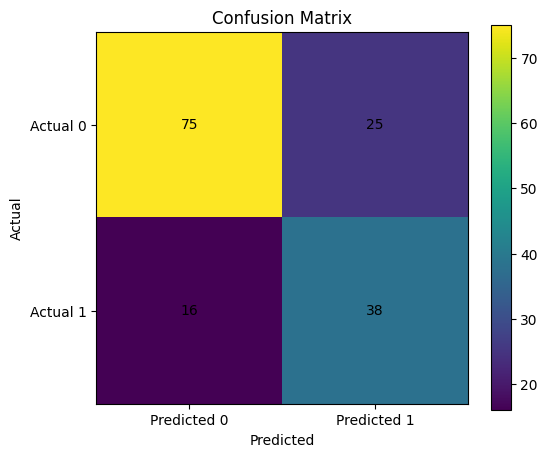

TN = 75, FP = 25, FN = 16, TP = 38


In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")

## 10. ROC Curve

ROC-AUC measures the model's ability to separate the two outcome classes across different classification thresholds.

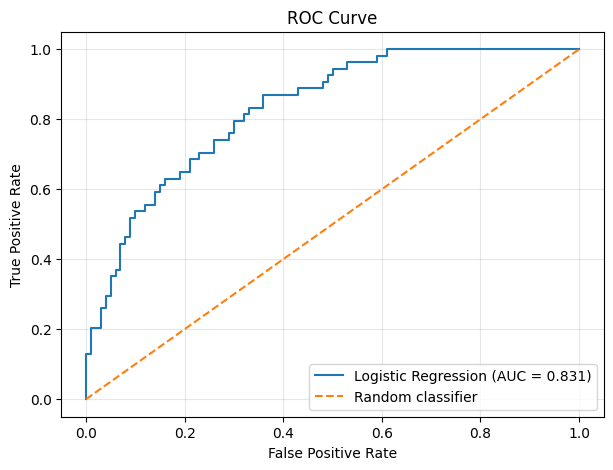

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 11. Interpret Model Coefficients

Positive coefficients increase the model's estimated probability of `Outcome = 1`, while negative coefficients decrease it. The coefficient magnitude is interpreted after standardization, so features are on a comparable scale.

,Feature,Coefficient
1,Glucose,0.9950
4,Insulin,0.5601
5,BMI,0.4203
0,Pregnancies,0.4175
3,SkinThickness,0.3718
6,DiabetesPedigreeFunction,0.3108
7,Age,0.1313
2,BloodPressure,-0.0807


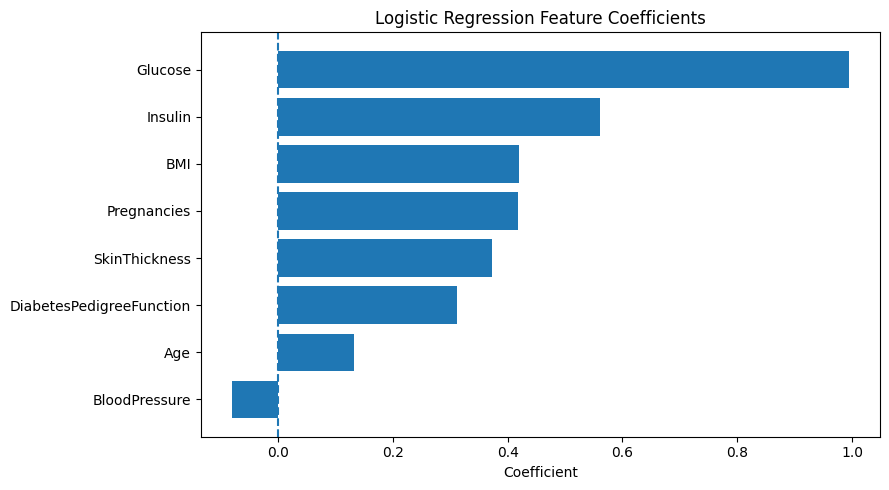

In [12]:
feature_names = X.columns
coefficients = model.named_steps["logistic_regression"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
}).sort_values("Coefficient", ascending=False)

display(coef_df[["Feature", "Coefficient"]].style.format({"Coefficient": "{:.4f}"}))

plt.figure(figsize=(9,5))
ordered = coef_df.sort_values("Coefficient")
plt.barh(ordered["Feature"], ordered["Coefficient"])
plt.axvline(0, linestyle="--")
plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

## 12. Key Findings

1. Logistic Regression provides a clear and interpretable binary classification baseline.
2. **Recall is important** in a screening-style task because false negatives represent positive cases that the model failed to detect.
3. The model coefficients show which standardized features contribute most strongly toward the predicted diabetes class.
4. The ROC-AUC summarizes the model's class-separation ability.
5. The supplied project brief reports approximately **0.734 accuracy, 0.603 precision, 0.704 recall, 0.650 F1-score and 0.813 ROC-AUC**, with confusion matrix **TN=75, FP=25, FN=16, TP=38**. With the supplied dataset and the reproducible `random_state=111` pipeline above, the confusion matrix and first four rounded metrics reproduce the brief; ROC-AUC can vary with the exact split/preprocessing implementation.

### Limitation
This is a small historical dataset representing a specific population. The model is suitable for learning machine-learning classification concepts and **must not be used as a medical diagnosis**.

## 13. Final Conclusion

**My conclusion:** I built a Logistic Regression model for diabetes prediction using the Pima Indians Diabetes dataset. I followed a complete machine-learning workflow: data inspection, invalid-zero handling, train-test splitting, median imputation, feature scaling, model training, and evaluation. The model's recall shows how many actual positive cases were detected, while ROC-AUC summarizes its ability to distinguish the two classes. This project helped me understand the practical use of Logistic Regression and evaluation metrics. The result should be treated as an educational classification exercise, not as a clinical diagnosis.

## 14. Submission Checklist

- [x] Dataset loaded and inspected
- [x] Preprocessing shown
- [x] Train-test split shown
- [x] Logistic Regression model trained
- [x] Accuracy, Precision, Recall, F1-score and ROC-AUC shown
- [x] Confusion matrix shown
- [x] ROC curve shown
- [x] Coefficient interpretation shown
- [x] Limitations and conclusion included
- [ ] Add/verify your own name, ID and date if required by the portal
- [ ] Keep all cell outputs visible before submitting
